In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

In [2]:
RAW_DATA_PATH = '../data/raw/raw_text.csv'
dataset = pd.read_csv(RAW_DATA_PATH)

# Display the first few rows of the dataset
dataset.head()


,Text,Label
0,We’re all going to a walk around the city Satu...,No
1,"Hey, I don’t want to say it too directly but… ...",Yes
2,"Lowkey, is the assignment due after class or S...",No
3,Can you check if my presentation i...,No
4,Can you grab me batteries on the ...,No


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 837 entries, 0 to 836
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    812 non-null    object
 1   Label   837 non-null    object
dtypes: object(2)
memory usage: 13.2+ KB


In [4]:
# Convert any labels value into only 1 and 0 
dataset['label'] = dataset['Label'].map({'Yes': 1, 'No': 0})
dataset['Text'] = dataset['Text'].astype(str) # Convert all text to string type

cleaned_dataset = dataset.dropna(subset=['Text', 'Label'])
# Fix: Do not use inplace=True to avoid NoneType error
cleaned_dataset = cleaned_dataset.drop_duplicates(subset=['Text'])

# Normalized whitespace
cleaned_dataset['Text'] = cleaned_dataset['Text'].replace(r"\s+", " ", regex=True).str.strip()
cleaned_dataset.to_csv("../data/cleaned/cleaned_dataset.csv",index=False)
cleaned_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 813 entries, 0 to 836
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    813 non-null    object
 1   Label   813 non-null    object
 2   label   813 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 25.4+ KB


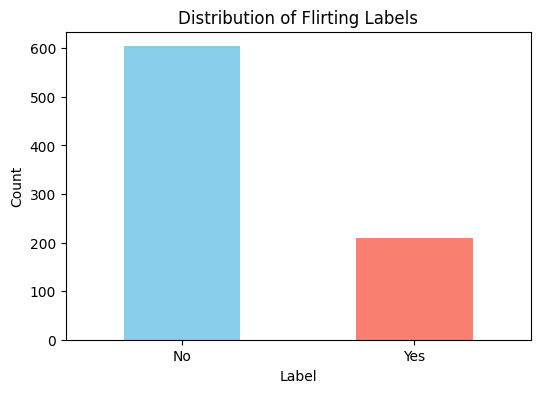

In [5]:
# distribution of labels
label_counts = cleaned_dataset['label'].value_counts()
plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Flirting Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'], rotation=0)
plt.show()


In [6]:
#Train test split dataset, %80 train, %10 val, %10 test, keeping the label distribution ratio the same
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(cleaned_dataset, test_size=0.2, random_state=42, stratify=cleaned_dataset['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])
len(train_df), len(val_df), len(test_df)

(650, 81, 82)

In [7]:
train_df.head()

,Text,Label,label
735,"Honestly, are you free tomorrow for a quick ca...",No,0
394,What bus do you usually take? ✨,No,0
302,"Lowkey, did you pay the bill for submission?",No,0
271,Please don’t forget to bring the drinks 😏,No,0
125,"Btw, can you check if my shop is correct? 😅",No,0


In [8]:
from datasets import Dataset
#Conver†ing pandas dataframes to huggingface datasets
#Benefits: efficient, faster, and compatible with transformers library

train_ds = Dataset.from_pandas(train_df[['Text', 'label']].reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df[['Text', 'label']].reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df[['Text', 'label']].reset_index(drop=True))

In [9]:
from transformers import AutoTokenizer
checkpoint = "distilbert/distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
#Tokenize the datasets
def tokenize_preprocess_function(examples):
    return tokenizer(examples["Text"], truncation=True)
train_tokenized = train_ds.map(tokenize_preprocess_function, batched=True)
val_tokenized = val_ds.map(tokenize_preprocess_function, batched=True)
test_tokenized = test_ds.map(tokenize_preprocess_function, batched=True)

#Dynamic padding and batching using DataCollator, 
#Pads each batch to the maximum length instead of a fixed max length
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Map:   0%|          | 0/650 [00:00<?, ? examples/s]

Map:   0%|          | 0/81 [00:00<?, ? examples/s]

Map:   0%|          | 0/82 [00:00<?, ? examples/s]

In [10]:
import evaluate
import numpy as np

accuracy_metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

id2label = {0: "No", 1: "Yes"}
label2id = {"No": 0, "Yes": 1} 

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)
training_args = TrainingArguments(
    output_dir="./flirt_distilbert",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    push_to_hub=False,
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer.train()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/phatcao/.venvs/jupyter/lib/python3.14/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.337318,0.753086
2,No log,0.160405,0.962963


/Users/phatcao/.venvs/jupyter/lib/python3.14/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=82, training_loss=0.3192804615672042, metrics={'train_runtime': 9.0923, 'train_samples_per_second': 142.979, 'train_steps_per_second': 9.019, 'total_flos': 6428808441024.0, 'train_loss': 0.3192804615672042, 'epoch': 2.0})

In [11]:
metric = trainer.evaluate(test_tokenized)
trainer.save_model("artifacts/flirt-distilbert")
tokenizer.save_pretrained("artifacts/flirt-distilbert")

/Users/phatcao/.venvs/jupyter/lib/python3.14/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


('artifacts/flirt-distilbert/tokenizer_config.json',
 'artifacts/flirt-distilbert/special_tokens_map.json',
 'artifacts/flirt-distilbert/vocab.txt',
 'artifacts/flirt-distilbert/added_tokens.json',
 'artifacts/flirt-distilbert/tokenizer.json')

In [12]:
metric


{'eval_loss': 0.14460307359695435,
 'eval_accuracy': 0.9878048780487805,
 'eval_runtime': 0.1577,
 'eval_samples_per_second': 519.967,
 'eval_steps_per_second': 38.046,
 'epoch': 2.0}

In [13]:
## Test on  the real sentences 

In [14]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_dir = "artifacts/flirt-distilbert"

tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)

id2label = {0: "No", 1: "Yes"}

def predict_text(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1).squeeze()

    pred = int(torch.argmax(probs))
    return id2label[pred], float(probs[pred])

In [22]:
def predict_text_threshold(text, yes_threshold=0.60, maybe_threshold=0.55):
    label, conf = predict_text(text) 

    # normalize label just in case
    label = label.strip().lower()

    if label == "yes" and conf >= yes_threshold:
        final_label = "Yes"
    elif label == "yes" and conf >= maybe_threshold:
        final_label = "Maybe"
    else:
        final_label = "No"

    return {
        "text": text,
        "label": final_label,
        "confidence": round(conf, 3)
    }

In [16]:
## Quick Test

In [23]:
easy_tests = [
    # YES (obvious flirting)
    "I miss you, when can I see you again?",
    "You looked really good today 😌",
    "You free tonight? Just us?",
    "I can't stop thinking about you",

    # NO (clearly not flirting)
    "Can you send me the report when you’re done?",
    "What time is the meeting tomorrow?",
    "Thanks for the update",
    "Please remember to submit the form",
]

medium_tests = [
    # YES (flirting mixed with normal)
    "Did you finish the report? Also I kinda miss talking to you",
    "Long day at work but your message made it better",
    "Thanks for helping earlier, I owe you dinner sometime 😏",
    "I should be sleeping but you’re distracting me",

    # NO (friendly / polite but not romantic)
    "I enjoy working with you, you’re easy to talk to",
    "That was a good discussion earlier, thanks",
    "You’re really reliable, I appreciate it",
    "This conversation was helpful",
]


hard_tests = [
   # YES (very subtle flirting)
    "I didn’t expect to enjoy this conversation so much",
    "You always seem to message at the right time",
    "This is random but I’m glad we talk",
    "I feel comfortable around you",

    # NO (can be misread as flirting)
    "You have good energy",
    "You’re different from what I expected",
    "That sounds nice actually",
    "I like your perspective",
]

tests = (
    [("Easy", t) for t in easy_tests] +
    [("Medium", t) for t in medium_tests] +
    [("Hard", t) for t in hard_tests]
)


for t in easy_tests:
    result = predict_text_threshold(t)
    print(f"Input: {result['text']}\nPredicted Label: {result['label']}, Confidence: {result['confidence']}\n")

for t in hard_tests:
    result = predict_text_threshold(t)
    print(f"Input: {result['text']}\nPredicted Label: {result['label']}, Confidence: {result['confidence']}\n")


Input: I miss you, when can I see you again?
Predicted Label: Yes, Confidence: 0.638

Input: You looked really good today 😌
Predicted Label: Maybe, Confidence: 0.576

Input: You free tonight? Just us?
Predicted Label: Yes, Confidence: 0.666

Input: I can't stop thinking about you
Predicted Label: Yes, Confidence: 0.661

Input: Can you send me the report when you’re done?
Predicted Label: No, Confidence: 0.98

Input: What time is the meeting tomorrow?
Predicted Label: No, Confidence: 0.979

Input: Thanks for the update
Predicted Label: No, Confidence: 0.971

Input: Please remember to submit the form
Predicted Label: No, Confidence: 0.966

Input: I didn’t expect to enjoy this conversation so much
Predicted Label: Yes, Confidence: 0.661

Input: You always seem to message at the right time
Predicted Label: No, Confidence: 0.503

Input: This is random but I’m glad we talk
Predicted Label: Yes, Confidence: 0.61

Input: I feel comfortable around you
Predicted Label: Yes, Confidence: 0.652

In